In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [29]:
df = pd.read_csv('forestfires.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nTarget distribution:")
print(df['size_category'].value_counts())

Shape: (517, 31)

First 5 rows:
  month  day  FFMC   DMC     DC  ISI  temp  RH  wind  rain  ...  monthfeb  \
0   mar  fri  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0  ...         0   
1   oct  tue  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0  ...         0   
2   oct  sat  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0  ...         0   
3   mar  fri  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2  ...         0   
4   mar  sun  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0  ...         0   

   monthjan  monthjul  monthjun  monthmar  monthmay  monthnov  monthoct  \
0         0         0         0         1         0         0         0   
1         0         0         0         0         0         0         1   
2         0         0         0         0         0         0         1   
3         0         0         0         1         0         0         0   
4         0         0         0         1         0         0         0   

   monthsep  size_category  
0         0          smal

In [30]:
df = pd.read_csv('forestfires.csv')

df['size_category'] = df['size_category'].astype(str).str.strip().str.lower()
df['size_category'] = df['size_category'].map({'small': 0, 'large': 1})
df = df.dropna(subset=['size_category'])

month_map = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
             'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
day_map   = {'mon':0,'tue':1,'wed':2,'thu':3,'fri':4,'sat':5,'sun':6}

df['month_num'] = df['month'].map(month_map)
df['day_num']   = df['day'].map(day_map)

df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)
df['day_sin']   = np.sin(2 * np.pi * df['day_num'] / 7)
df['day_cos']   = np.cos(2 * np.pi * df['day_num'] / 7)

feature_cols = ['FFMC','DMC','DC','ISI','temp','RH','wind','rain',
                'month_sin','month_cos','day_sin','day_cos']

X = df[feature_cols].values
y = df['size_category'].astype(int).values

print("X shape:", X.shape)
print("y distribution:", dict(zip(*np.unique(y, return_counts=True))))

X shape: (517, 12)
y distribution: {0: 378, 1: 139}


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train class balance:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Test  class balance:", dict(zip(*np.unique(y_test,  return_counts=True))))

Train: (413, 12)  Test: (104, 12)
Train class balance: {0: 302, 1: 111}
Test  class balance: {0: 76, 1: 28}


In [32]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights_array))
print("Class weights:", class_weights)

Class weights: {0: 0.6837748344370861, 1: 1.8603603603603605}


In [33]:
tf.random.set_seed(42)
np.random.seed(42)

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 192 (768.00 B)

In [34]:
early_stop = EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - accuracy: 0.5121 - auc: 0.5820 - loss: 0.7089 - val_accuracy: 0.3012 - val_auc: 0.4658 - val_loss: 0.7309
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.4970 - auc: 0.5765 - loss: 0.7202 - val_accuracy: 0.5301 - val_auc: 0.5949 - val_loss: 0.7013
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5212 - auc: 0.6026 - loss: 0.6854 - val_accuracy: 0.5663 - val_auc: 0.6210 - val_loss: 0.6857
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.5303 - auc: 0.5805 - loss: 0.7246 - val_accuracy: 0.5783 - val_auc: 0.6045 - val_loss: 0.6885
Epoch 5/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.5545 - auc: 0.6287 - loss: 0.6871 - val_accuracy: 0.5783 - val_auc: 0.6006 - val_loss: 0.6834
Epoch 6/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5364 - auc: 0.5940 - loss: 0.7081 - val_accuracy: 0.6024 - val_auc: 0.6194 - val_loss: 0.6759
Epoch 7/200
21/21 ━━━━━━━━━━━━━━━━━━━━

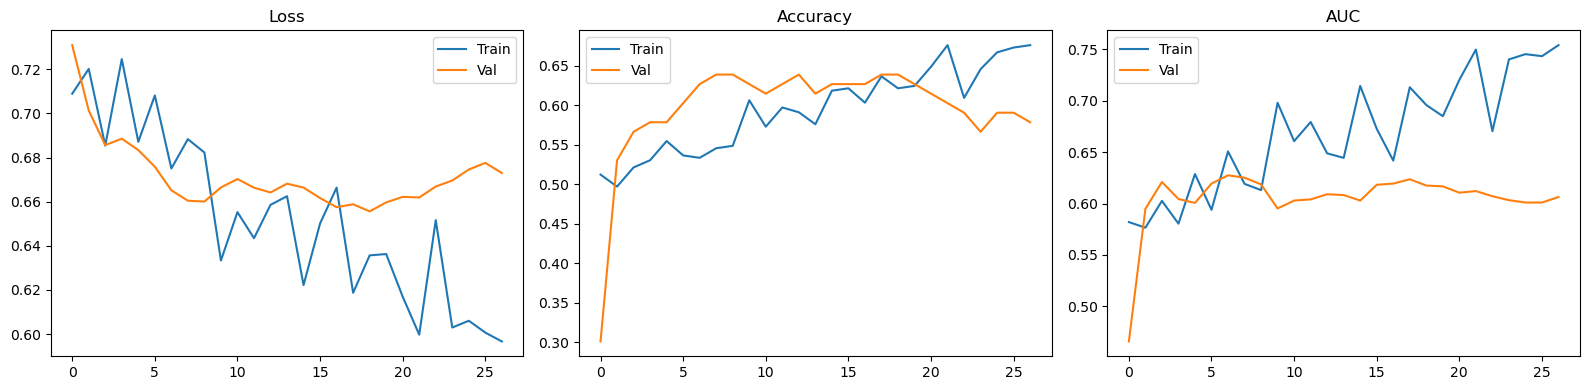

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy')
axes[1].legend()

axes[2].plot(history.history['auc'], label='Train')
axes[2].plot(history.history['val_auc'], label='Val')
axes[2].set_title('AUC')
axes[2].legend()

plt.tight_layout()
plt.show()

In [36]:
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_pred_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=['small', 'large'],
                            zero_division=0))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step
Accuracy: 0.5961538461538461
ROC-AUC : 0.5401785714285714

Confusion Matrix:
[[46 30]
 [12 16]]

Classification Report:
              precision    recall  f1-score   support

       small       0.79      0.61      0.69        76
       large       0.35      0.57      0.43        28

    accuracy                           0.60       104
   macro avg       0.57      0.59      0.56       104
weighted avg       0.67      0.60      0.62       104



In [37]:
print("Threshold tuning:\n")
best_f1 = 0
best_thresh = 0.5

for thresh in np.arange(0.2, 0.81, 0.05):
    preds = (y_pred_prob > thresh).astype(int)
    report = classification_report(y_test, preds,
                                   target_names=['small','large'],
                                   output_dict=True, zero_division=0)
    f1_large = report['large']['f1-score']
    rec_large = report['large']['recall']
    prec_large = report['large']['precision']
    print(f"thresh={thresh:.2f} | large prec={prec_large:.2f} "
          f"rec={rec_large:.2f} f1={f1_large:.2f}")
    if f1_large > best_f1:
        best_f1 = f1_large
        best_thresh = thresh

print(f"\n>>> Best threshold for 'large' F1: {best_thresh:.2f} (F1={best_f1:.2f})")

Threshold tuning:

thresh=0.20 | large prec=0.27 rec=1.00 f1=0.42
thresh=0.25 | large prec=0.27 rec=1.00 f1=0.42
thresh=0.30 | large prec=0.27 rec=1.00 f1=0.43
thresh=0.35 | large prec=0.26 rec=0.96 f1=0.42
thresh=0.40 | large prec=0.27 rec=0.89 f1=0.41
thresh=0.45 | large prec=0.26 rec=0.71 f1=0.38
thresh=0.50 | large prec=0.35 rec=0.57 f1=0.43
thresh=0.55 | large prec=0.36 rec=0.29 f1=0.32
thresh=0.60 | large prec=0.17 rec=0.04 f1=0.06
thresh=0.65 | large prec=1.00 rec=0.04 f1=0.07
thresh=0.70 | large prec=0.00 rec=0.00 f1=0.00
thresh=0.75 | large prec=0.00 rec=0.00 f1=0.00
thresh=0.80 | large prec=0.00 rec=0.00 f1=0.00

>>> Best threshold for 'large' F1: 0.50 (F1=0.43)


In [38]:
y_pred_best = (y_pred_prob > best_thresh).astype(int)

print(f"=== Final results at threshold {best_thresh:.2f} ===\n")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("ROC-AUC :", roc_auc_score(y_test, y_pred_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best,
                            target_names=['small', 'large'],
                            zero_division=0))

=== Final results at threshold 0.50 ===

Accuracy: 0.5961538461538461
ROC-AUC : 0.5401785714285714

Confusion Matrix:
[[46 30]
 [12 16]]

Classification Report:
              precision    recall  f1-score   support

       small       0.79      0.61      0.69        76
       large       0.35      0.57      0.43        28

    accuracy                           0.60       104
   macro avg       0.57      0.59      0.56       104
weighted avg       0.67      0.60      0.62       104



In [39]:
sample = X_test[0:1]
sample_prob = model.predict(sample).ravel()[0]
sample_pred = int(sample_prob > best_thresh)
actual = y_test[0]

print(f"Predicted probability of 'large': {sample_prob:.3f}")
print(f"Predicted class (thresh={best_thresh:.2f}): {'large' if sample_pred else 'small'}")
print(f"Actual class: {'large' if actual else 'small'}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
Predicted probability of 'large': 0.496
Predicted class (thresh=0.50): small
Actual class: small


In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred,
                            target_names=['small','large'],
                            zero_division=0))

rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                            random_state=42, max_depth=10)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred,
                            target_names=['small','large'],
                            zero_division=0))

=== Logistic Regression ===
Accuracy: 0.4519230769230769
              precision    recall  f1-score   support

       small       0.69      0.45      0.54        76
       large       0.24      0.46      0.31        28

    accuracy                           0.45       104
   macro avg       0.47      0.46      0.43       104
weighted avg       0.57      0.45      0.48       104


=== Random Forest ===
Accuracy: 0.625
              precision    recall  f1-score   support

       small       0.72      0.80      0.76        76
       large       0.21      0.14      0.17        28

    accuracy                           0.62       104
   macro avg       0.46      0.47      0.46       104
weighted avg       0.58      0.62      0.60       104

